In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection


Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Original DataFrame head:
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      

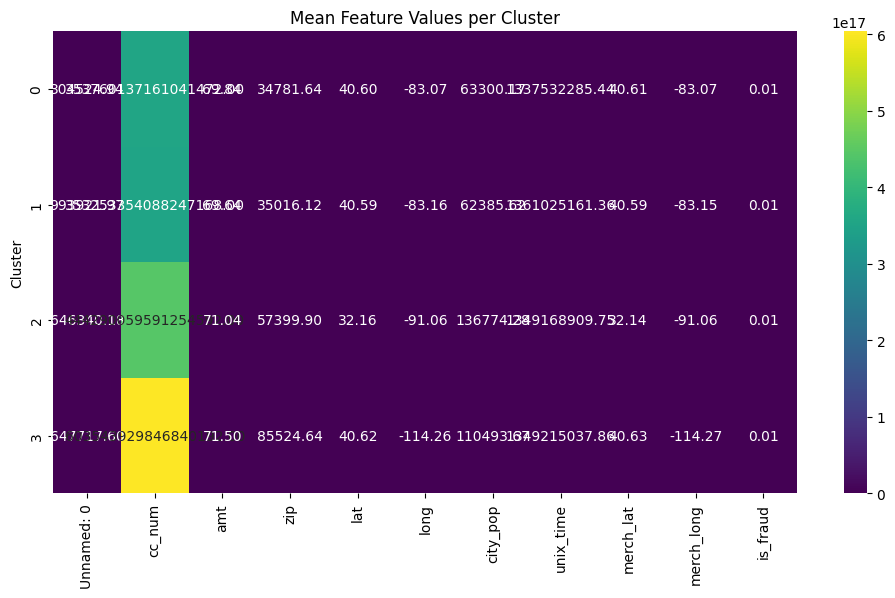


Cluster Characteristics (Standard Deviation for each feature within each cluster):
            Unnamed: 0        cc_num         amt           zip       lat  \
Cluster                                                                    
0        186630.108532  1.220257e+18  157.061796  20221.865657  2.997929   
1        185851.860330  1.219181e+18  147.230936  20227.664282  3.032186   
2        340753.267907  1.348142e+18  176.952652  20387.283252  2.830581   
3        357623.599663  1.519590e+18  162.534067  12186.750800  5.642694   

              long       city_pop     unix_time  merch_lat  merch_long  \
Cluster                                                                  
0         7.687621  240747.405520  6.582485e+06   3.037014    7.704395   
1         7.689484  238065.101895  6.606119e+06   3.070754    7.707701   
2         6.783358  412389.414677  1.162316e+07   2.861930    6.805085   
3        10.222216  298339.121110  1.224470e+07   5.675401   10.227169   

         is_fr

In [7]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Download latest version to ensure 'path' is defined
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print(f"Path to dataset files: {path}")

# Assuming the dataset is a CSV file named 'fraudTrain.csv' inside the path
# If this is not the case, you might need to adjust the file path
file_path = os.path.join(path, 'fraudTrain.csv') # Adjusted filename to fraudTrain.csv

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the dataset contents.")
    # List files in the directory to help the user
    print("Files in dataset directory:", os.listdir(path))
    exit()

print("Original DataFrame head:")
print(df.head())
print("\nOriginal DataFrame info:")
df.info()

# Separate features for clustering, ignoring the last column
# Make a copy to avoid SettingWithCopyWarning
X = df.iloc[:, :-1].copy()

print("\nFeatures for clustering head (last column dropped):")
print(X.head())

# Handle potential non-numeric data or NaNs if any (simple drop for now)
X = X.select_dtypes(include=['number']).dropna()

if X.empty:
    print("Error: No numeric features left after dropping the last column and non-numeric/NaN values. Cannot perform clustering.")
else:
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform K-Means clustering
    # Let's start with 3 clusters, this can be optimized using methods like the Elbow method
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init is important for robust results
    clusters = kmeans.fit_predict(X_scaled)

    # Add cluster labels to the original dataframe
    df_clustered = df.copy()
    df_clustered['Cluster'] = clusters

    print(f"\nK-Means clustering performed with {n_clusters} clusters.")
    print("Cluster distribution:")
    print(df_clustered['Cluster'].value_counts())

    # Analyze cluster characteristics
    print("\nCluster Characteristics (Mean values for each feature within each cluster):")
    # Fix: Add numeric_only=True to ignore non-numeric columns when calculating mean
    cluster_means = df_clustered.groupby('Cluster').mean(numeric_only=True)
    print(cluster_means)

    # You can also visualize the characteristics, for example, using a heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(cluster_means, annot=True, cmap='viridis', fmt=".2f")
    plt.title('Mean Feature Values per Cluster')
    plt.show()

    # For a more detailed look, you could also check the standard deviations
    print("\nCluster Characteristics (Standard Deviation for each feature within each cluster):")
    # Fix: Add numeric_only=True to ignore non-numeric columns when calculating std
    cluster_stds = df_clustered.groupby('Cluster').std(numeric_only=True)
    print(cluster_stds)

    # If the last column was meant for checking (e.g., target variable), you can analyze its distribution per cluster
    if df.shape[1] > X.shape[1]:
        last_col_name = df.columns[-1]
        print(f"\nDistribution of '{last_col_name}' (the ignored column) per cluster:")
        print(df_clustered.groupby('Cluster')[last_col_name].value_counts(normalize=True))

        # --- New code for classification metrics based on clusters and 'is_fraud' ---
        print("\n--- Classification Metrics (treating clusters as predictors for 'is_fraud') ---")

        # Define true labels
        y_true = df_clustered[last_col_name]

        # Determine the majority class for 'is_fraud' within each cluster
        # If a cluster has both 0s and 1s, mode() will return the most frequent one.
        # If there's a tie, it picks the first (0 in this case for 'is_fraud').
        cluster_majority_class = df_clustered.groupby('Cluster')[last_col_name].apply(lambda x: x.mode()[0])

        # Map these majority classes back to create predicted labels for each data point
        y_pred = df_clustered['Cluster'].map(cluster_majority_class)

        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

        # Create a DataFrame for easy viewing
        metrics_table = pd.DataFrame({
            'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            'Value': [accuracy, precision, recall, f1]
        })
        print(metrics_table.to_string(index=False))

        print("\nNote: These metrics are calculated by assigning each cluster the majority 'is_fraud' label present within it. This is not a traditional classification model, but a way to assess the alignment of clustering with the 'is_fraud' target.")


In [8]:
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import sys # Import sys for sys.exit()

# Ensure X_scaled and last_col_name are available from previous cells
# If running this cell independently, make sure 'df', 'X', 'X_scaled' are defined.

if 'df' not in locals() or 'X' not in locals() or 'X_scaled' not in locals():
    print("\n--- DEPENDENCY ERROR ---")
    print("Error: Required variables ('df', 'X', 'X_scaled') not found.")
    print("Please ensure the data preprocessing cell (e.g., cell `4jbz2SXn4EpK`) has been run successfully before executing this cell.")
    print("------------------------")
    sys.exit("Exiting cell execution due to missing dependencies.") # Exit execution
else:
    print("\n--- Performing DBSCAN Clustering ---")

    # Initialize DBSCAN
    # eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    # min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
    # These parameters are highly sensitive and often require tuning.
    # n_jobs: The number of parallel jobs to use. -1 means using all processors.
    # Note: A large 'eps' can significantly slow down computation.
    dbscan = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1) # Example values, often require extensive tuning

    # Perform DBSCAN clustering
    dbscan_clusters = dbscan.fit_predict(X_scaled)

    # Add cluster labels to the original dataframe
    # Make a copy to avoid SettingWithCopyWarning if df is directly modified
    df_dbscan_clustered = df.copy()
    df_dbscan_clustered['DBSCAN_Cluster'] = dbscan_clusters

    print("DBSCAN clustering performed.")
    print("Cluster distribution (including -1 for noise points):")
    print(df_dbscan_clustered['DBSCAN_Cluster'].value_counts())

    # Analyze cluster characteristics for non-noise clusters
    non_noise_clusters = df_dbscan_clustered[df_dbscan_clustered['DBSCAN_Cluster'] != -1]
    if not non_noise_clusters.empty:
        print("\nCluster Characteristics (Mean values for each feature within each non-noise cluster):")
        cluster_means_dbscan = non_noise_clusters.groupby('DBSCAN_Cluster').mean(numeric_only=True)
        print(cluster_means_dbscan)

        # Visualize cluster characteristics if there are few enough clusters
        if len(cluster_means_dbscan) > 0 and len(cluster_means_dbscan) < 20: # Limit for readability
            plt.figure(figsize=(14, 7))
            sns.heatmap(cluster_means_dbscan, annot=True, cmap='viridis', fmt=".2f")
            plt.title('Mean Feature Values per DBSCAN Cluster (excluding noise)')
            plt.show()
        else:
            print("Skipping heatmap visualization due to too many clusters or no non-noise clusters.")

    # If the last column was meant for checking (e.g., target variable), analyze its distribution per cluster
    if 'last_col_name' in locals() and df.shape[1] > X.shape[1]:
        print(f"\nDistribution of '{last_col_name}' (the ignored column) per DBSCAN cluster:")
        print(df_dbscan_clustered.groupby('DBSCAN_Cluster')[last_col_name].value_counts(normalize=True))

        # --- New code for classification metrics based on DBSCAN clusters and 'is_fraud' ---
        print("\n--- Classification Metrics (treating DBSCAN clusters as predictors for 'is_fraud') ---")

        # Filter out noise points for metrics calculation if they are not to be considered as a class
        # Or, treat noise as its own class. For now, let's include noise but be aware.
        y_true_dbscan = df_dbscan_clustered[last_col_name]

        # Determine the majority class for 'is_fraud' within each cluster (including noise if present)
        cluster_majority_class_dbscan = df_dbscan_clustered.groupby('DBSCAN_Cluster')[last_col_name].apply(lambda x: x.mode()[0] if not x.mode().empty else 0) # Default to 0 if no mode (e.g., empty cluster)

        # Map these majority classes back to create predicted labels for each data point
        y_pred_dbscan = df_dbscan_clustered['DBSCAN_Cluster'].map(cluster_majority_class_dbscan)

        # Calculate metrics
        accuracy_dbscan = accuracy_score(y_true_dbscan, y_pred_dbscan)
        precision_dbscan = precision_score(y_true_dbscan, y_pred_dbscan, average='binary', zero_division=0)
        recall_dbscan = recall_score(y_true_dbscan, y_pred_dbscan, average='binary', zero_division=0)
        f1_dbscan = f1_score(y_true_dbscan, y_pred_dbscan, average='binary', zero_division=0)

        # Create a DataFrame for easy viewing
        metrics_table_dbscan = pd.DataFrame({
            'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            'Value': [accuracy_dbscan, precision_dbscan, recall_dbscan, f1_dbscan]
        })
        print(metrics_table_dbscan.to_string(index=False))

        print("\nNote: These metrics are calculated by assigning each DBSCAN cluster (including noise, if any) the majority 'is_fraud' label present within it. This is not a traditional classification model, but a way to assess the alignment of clustering with the 'is_fraud' target.")
    else:
        print("\n'last_col_name' not found or target analysis not applicable.")


--- Performing DBSCAN Clustering ---
DBSCAN clustering performed.
Cluster distribution (including -1 for noise points):
DBSCAN_Cluster
0      1074642
12       21611
13       17218
18        8548
33        8540
        ...   
245          3
100          3
91           2
156          1
178          1
Name: count, Length: 259, dtype: int64

Cluster Characteristics (Mean values for each feature within each non-noise cluster):
                  Unnamed: 0        cc_num         amt           zip  \
DBSCAN_Cluster                                                         
0               6.485166e+05  2.345885e+15   64.460787  47350.477969   
1               6.323059e+05  4.956829e+18   47.242140   7208.000000   
2               6.447007e+05  4.710649e+18   62.988218   6554.312718   
3               6.523809e+05  4.392192e+18   50.318271  51895.452204   
4               6.583741e+05  4.534528e+18   48.809639  96756.248514   
...                      ...           ...         ...           ... 


--- Visualizing K-Means Clusters ---


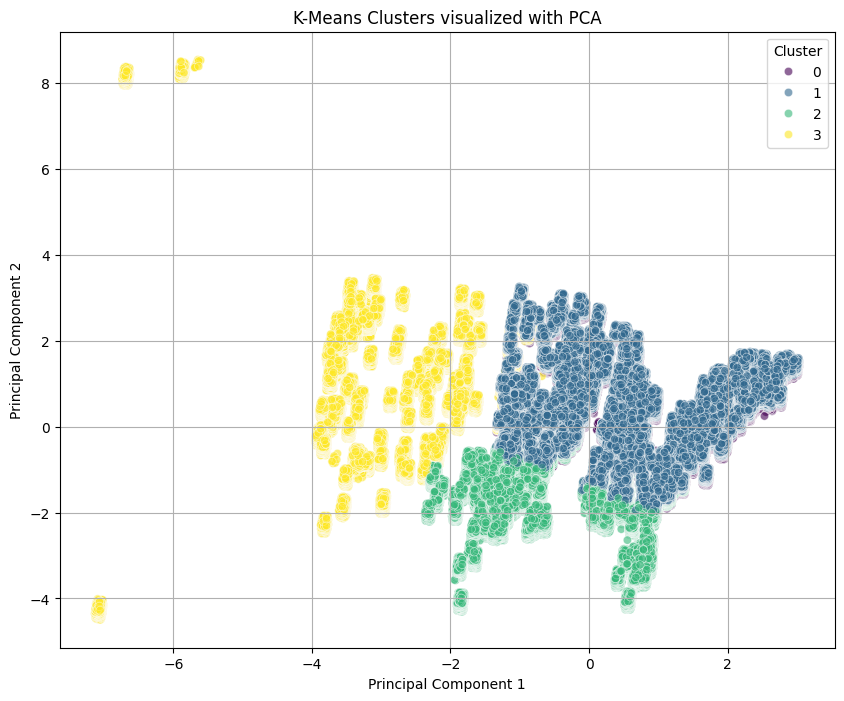

Visualization complete. Each color represents a different K-Means cluster.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

# Ensure X_scaled and clusters are available
if 'X_scaled' not in locals() or 'clusters' not in locals():
    print("Error: 'X_scaled' or 'clusters' not found. Please run the data preprocessing cell first (cell 4jbz2SXn4EpK).")
else:
    print("\n--- Visualizing K-Means Clusters ---")

    # Reduce dimensions for visualization using PCA
    # PCA is a common technique to visualize high-dimensional data in 2D or 3D.
    pca = PCA(n_components=2) # Reduce to 2 dimensions for a 2D plot
    X_pca = pca.fit_transform(X_scaled)

    # Create a DataFrame for plotting
    pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
    pca_df['Cluster'] = clusters

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='Principal Component 1',
        y='Principal Component 2',
        hue='Cluster',
        data=pca_df,
        palette='viridis',
        legend='full',
        alpha=0.6
    )
    plt.title('K-Means Clusters visualized with PCA')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()

    print("Visualization complete. Each color represents a different K-Means cluster.")


--- Performing K-Means Clustering on PCA-transformed Data ---
Data reduced to 2 principal components, capturing 49.44% of variance.

K-Means clustering performed on PCA data with 4 clusters.
Cluster distribution (PCA K-Means):
PCA_KMeans_Cluster
2    407274
1    380520
0    328908
3    179973
Name: count, dtype: int64

Cluster Characteristics (Mean values for each original feature within each PCA K-Means cluster):
                       Unnamed: 0        cc_num        amt           zip  \
PCA_KMeans_Cluster                                                         
0                   655569.064997  3.758855e+17  68.845543  56867.014174   
1                   640737.418990  4.687707e+17  70.676007  54041.201451   
2                   649203.830011  3.294857e+17  70.732377  19148.478803   
3                   649226.417890  5.821048e+17  71.552326  90081.060854   

                          lat        long       city_pop     unix_time  \
PCA_KMeans_Cluster                                

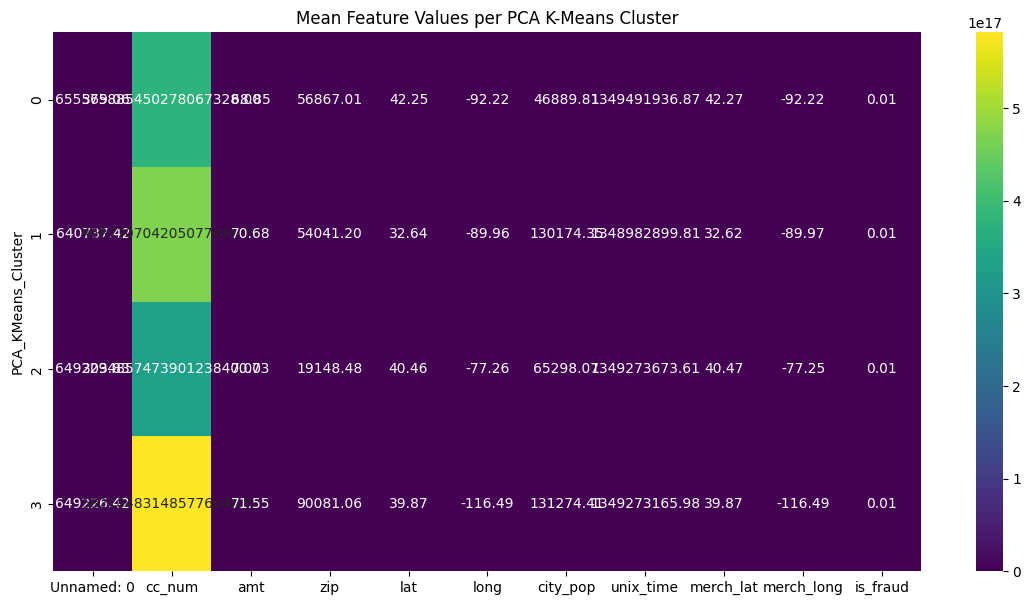

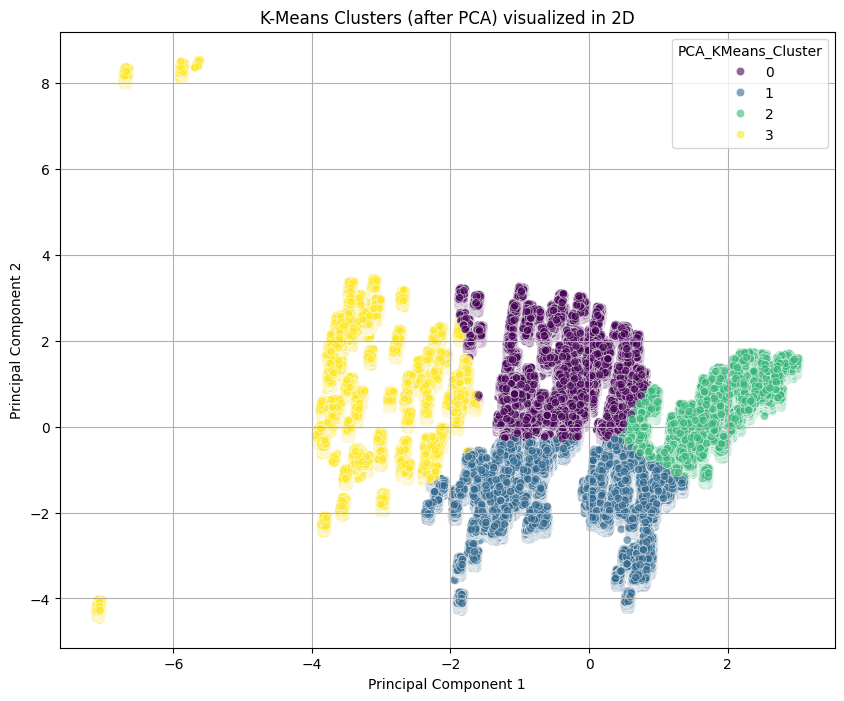


Distribution of 'is_fraud' (the ignored column) per PCA K-Means cluster:
PCA_KMeans_Cluster  is_fraud
0                   0           0.994427
                    1           0.005573
1                   0           0.994400
                    1           0.005600
2                   0           0.993950
                    1           0.006050
3                   0           0.994010
                    1           0.005990
Name: proportion, dtype: float64

--- Classification Metrics (treating PCA K-Means clusters as predictors for 'is_fraud') ---
   Metric    Value
 Accuracy 0.994211
Precision 0.000000
   Recall 0.000000
 F1-Score 0.000000

Note: These metrics are calculated by assigning each PCA K-Means cluster the majority 'is_fraud' label present within it. This assesses clustering alignment with the target.


In [11]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure X_scaled and n_clusters are available
if 'X_scaled' not in locals() or 'n_clusters' not in locals() or 'df' not in locals():
    print("Error: 'X_scaled', 'n_clusters', or 'df' not found. Please run the data preprocessing cell first (cell 4jbz2SXn4EpK).")
else:
    print("\n--- Performing K-Means Clustering on PCA-transformed Data ---")

    # 1. Apply PCA to reduce dimensionality
    # Reducing to 2 components for easy visualization, but this can be tuned.
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    print(f"Data reduced to {pca.n_components_} principal components, capturing {pca.explained_variance_ratio_.sum():.2%} of variance.")

    # 2. Perform K-Means clustering on the PCA-transformed data
    kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Using existing n_clusters
    clusters_pca = kmeans_pca.fit_predict(X_pca)

    # Add cluster labels to the original dataframe
    df_clustered_pca = df.copy()
    df_clustered_pca['PCA_KMeans_Cluster'] = clusters_pca

    print(f"\nK-Means clustering performed on PCA data with {n_clusters} clusters.")
    print("Cluster distribution (PCA K-Means):")
    print(df_clustered_pca['PCA_KMeans_Cluster'].value_counts())

    # 3. Analyze cluster characteristics
    print("\nCluster Characteristics (Mean values for each original feature within each PCA K-Means cluster):")
    # It's often useful to look at original feature means, though clustering was done on PCA components.
    cluster_means_pca = df_clustered_pca.groupby('PCA_KMeans_Cluster').mean(numeric_only=True)
    print(cluster_means_pca)

    # Visualize cluster characteristics if there are few enough clusters
    if len(cluster_means_pca) > 0 and len(cluster_means_pca) < 20: # Limit for readability
        plt.figure(figsize=(14, 7))
        sns.heatmap(cluster_means_pca, annot=True, cmap='viridis', fmt=".2f")
        plt.title('Mean Feature Values per PCA K-Means Cluster')
        plt.show()

    # 4. Visualize the PCA K-Means Clusters
    pca_df_kmeans = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
    pca_df_kmeans['PCA_KMeans_Cluster'] = clusters_pca

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='Principal Component 1',
        y='Principal Component 2',
        hue='PCA_KMeans_Cluster',
        data=pca_df_kmeans,
        palette='viridis',
        legend='full',
        alpha=0.6
    )
    plt.title('K-Means Clusters (after PCA) visualized in 2D')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()

    # If the last column was meant for checking (e.g., target variable), analyze its distribution per cluster
    if 'last_col_name' in locals() and df.shape[1] > X.shape[1]:
        print(f"\nDistribution of '{last_col_name}' (the ignored column) per PCA K-Means cluster:")
        print(df_clustered_pca.groupby('PCA_KMeans_Cluster')[last_col_name].value_counts(normalize=True))

        # --- Classification metrics (treating PCA K-Means clusters as predictors for 'is_fraud') ---
        print("\n--- Classification Metrics (treating PCA K-Means clusters as predictors for 'is_fraud') ---")

        y_true_pca_kmeans = df_clustered_pca[last_col_name]
        cluster_majority_class_pca_kmeans = df_clustered_pca.groupby('PCA_KMeans_Cluster')[last_col_name].apply(lambda x: x.mode()[0])
        y_pred_pca_kmeans = df_clustered_pca['PCA_KMeans_Cluster'].map(cluster_majority_class_pca_kmeans)

        accuracy_pca_kmeans = accuracy_score(y_true_pca_kmeans, y_pred_pca_kmeans)
        precision_pca_kmeans = precision_score(y_true_pca_kmeans, y_pred_pca_kmeans, average='binary', zero_division=0)
        recall_pca_kmeans = recall_score(y_true_pca_kmeans, y_pred_pca_kmeans, average='binary', zero_division=0)
        f1_pca_kmeans = f1_score(y_true_pca_kmeans, y_pred_pca_kmeans, average='binary', zero_division=0)

        metrics_table_pca_kmeans = pd.DataFrame({
            'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            'Value': [accuracy_pca_kmeans, precision_pca_kmeans, recall_pca_kmeans, f1_pca_kmeans]
        })
        print(metrics_table_pca_kmeans.to_string(index=False))

        print("\nNote: These metrics are calculated by assigning each PCA K-Means cluster the majority 'is_fraud' label present within it. This assesses clustering alignment with the target.")
    else:
        print("\n'last_col_name' not found or target analysis not applicable.")
